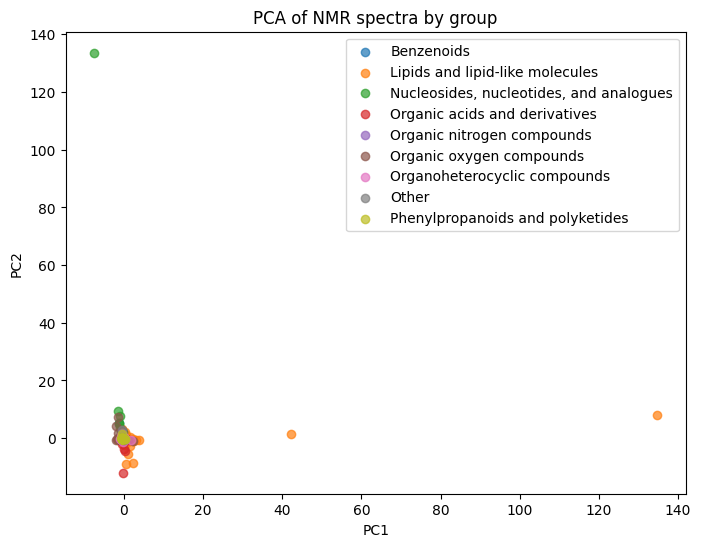

Random Forest CV accuracy: 0.527 ± 0.026
SVM CV accuracy: 0.399 ± 0.021


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt

# -------------------------
# 1. Load your features + groups
# -------------------------
# Suppose your CSV has columns:
# accession, group, peak1, peak2, ..., peakN
df = pd.read_csv("nmr_features_with_groups.csv")

X = df.drop(columns=["accession", "group"]).values
y = df["group"].values

# -------------------------
# 2. Standardize features
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# 3. PCA for visualization
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for g in np.unique(y):
    idx = (y == g)
    plt.scatter(X_pca[idx,0], X_pca[idx,1], label=g, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of NMR spectra by group")
plt.legend()
plt.show()

# -------------------------
# 4. Random Forest classifier
# -------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_scores = cross_val_score(rf, X_scaled, y, cv=cv)
print("Random Forest CV accuracy: %.3f ± %.3f" % (rf_scores.mean(), rf_scores.std()))

# -------------------------
# 5. Support Vector Machine classifier
# -------------------------
svm = SVC(kernel="rbf", C=1, gamma="scale")
svm_scores = cross_val_score(svm, X_scaled, y, cv=cv)
print("SVM CV accuracy: %.3f ± %.3f" % (svm_scores.mean(), svm_scores.std()))


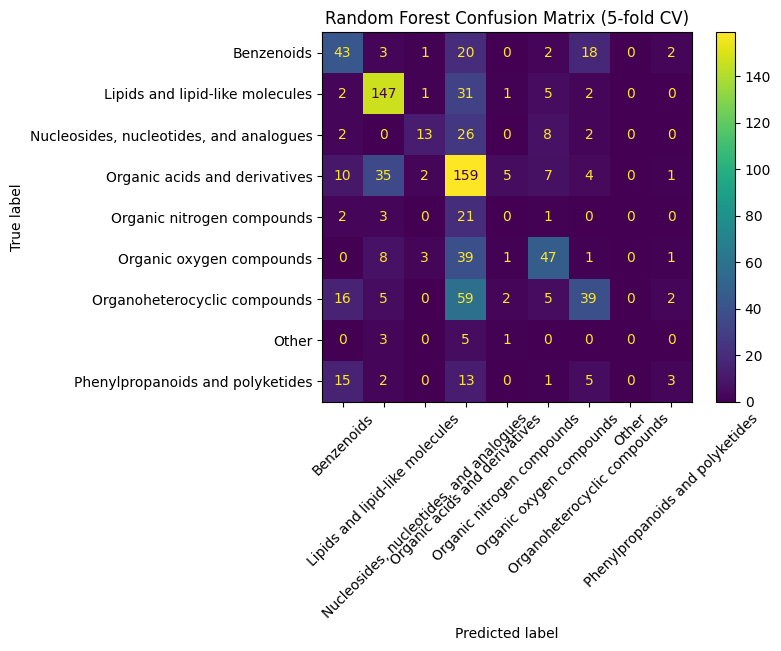

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

# Predict with cross-validation
y_pred = cross_val_predict(rf, X_scaled, y, cv=cv)

# Confusion matrix
cm = confusion_matrix(y, y_pred, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
disp.plot(xticks_rotation=45, cmap="viridis")
plt.title("Random Forest Confusion Matrix (5-fold CV)")
plt.show()
